# Step 1 – Copper-Plate Market Clearing (Single Hour)

## Market-Clearing Mechanism

The market-clearing problem maximizes social welfare:

$$
\max \left(
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}
\right)
$$

subject to the power balance constraint:

$$
\sum_{i \in \mathcal{G}} p_{i,t}
+
\sum_{w \in \mathcal{W}} p_{w,t}
=
\sum_{d \in \mathcal{D}} d_{d,t}.
$$

The dual variable associated with the power balance constraint is the market-clearing price:

$$
\lambda_t.
$$

Under uniform pricing, all accepted generators and demands are settled at this price.

---

## Merit-Order Dispatch

Conventional generators are dispatched according to increasing marginal costs $C_i$.

The economic logic is:

- If $C_i < \lambda_t$ → the generator is **fully dispatched**.
- If $C_i = \lambda_t$ → the generator is **marginal** (partially dispatched).
- If $C_i > \lambda_t$ → the generator is **not dispatched**.

Renewable generators (wind) are modeled with zero marginal cost:

$$
C_w = 0,
$$

and are therefore dispatched up to their available capacity:

$$
0 \le p_{w,t} \le \bar{P}_{w,t}.
$$

---

## Welfare Decomposition

Social welfare is defined as:

$$
SW =
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}.
$$

Producer profit for generator $i$:

$$
\Pi_i = (\lambda_t - C_i) p_{i,t}.
$$

Demand utility for consumer $d$:

$$
\text{Utility}_d = d_{d,t}(U_d - \lambda_t).
$$

Infra-marginal generators earn positive profits, while the marginal generator earns zero profit.

---

## KKT Conditions and Price Formation

The stationarity condition for each generator is:

$$
C_i - \lambda_t + \mu_i^{\max} - \mu_i^{\min} = 0,
$$

where:

- $\mu_i^{\max}$ is the multiplier of the upper bound constraint,
- $\mu_i^{\min}$ is the multiplier of the lower bound constraint.

Three cases arise:

1. **Marginal unit:**  
   $p_{i,t} > 0$ and not at a bound  
   $$C_i = \lambda_t.$$

2. **Infra-marginal unit (capacity constrained):**  
   $p_{i,t} = P_i^{\max}$  
   $$C_i < \lambda_t.$$

3. **Rejected unit:**  
   $p_{i,t} = 0$  
   $$C_i > \lambda_t.$$

Thus, the market-clearing price equals the marginal accepted bid, confirming the economic interpretation of the dual variable $\lambda_t$.

In [58]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os

# ============================================
# SETS
# ============================================

G = range(12)         # i ∈ 𝒢 (conventional generators)
W = [1,2,3,4,5,6]     # w ∈ 𝒲 (single aggregated wind unit)
D_set = [0]           # d ∈ 𝒟 (single aggregated demand)

# ============================================
# PARAMETERS
# ============================================

# Generator parameters
P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# Demand parameters
D_t = 2650.5          # total system demand
U_d = 100             # demand bid price

# ============================================
# WIND DATA IMPORT
# ============================================
wind_file = os.path.join("data", "processed", "wind_available_power_6_nodes_MW.csv")

wind_data = pd.read_csv(wind_file)

# Choose a specific hour (for example hour 18 peak denmand)
hour_star = 18

row = wind_data[wind_data["hour"] == hour_star]

P_w_bar = {
    1: row["wind_3"].values[0],
    2: row["wind_5"].values[0],
    3: row["wind_7"].values[0],
    4: row["wind_16"].values[0],
    5: row["wind_21"].values[0],
    6: row["wind_23"].values[0]
}
    
# ============================================
# REPORT INPUT SUMMARY
# ============================================

print("\n========== INPUT SUMMARY ==========")
print(f"Selected hour (wind peak): t = {hour_star}")
print(f"Total demand D_t: {D_t:.2f} MW")
print("\nWind availability per wind farm:")
for w in W:
    print(f"W{w}: {P_w_bar[w]:.2f} MW")

total_wind = sum(P_w_bar.values())
print(f"\nTotal wind availability: {total_wind:.2f} MW")
    
print(f"Demand bid U_d: {U_d:.2f} €/MWh")

total_capacity = sum(P_max[i] for i in G)
print(f"Total conventional capacity Σ P_i^max: {total_capacity:.2f} MW")



========== INPUT SUMMARY ==========
Selected hour (wind peak): t = 18
Total demand D_t: 2650.50 MW

Wind availability per wind farm:
W1: 56.85 MW
W2: 64.45 MW
W3: 84.63 MW
W4: 33.48 MW
W5: 65.02 MW
W6: 81.37 MW

Total wind availability: 385.81 MW
Demand bid U_d: 100.00 €/MWh
Total conventional capacity Σ P_i^max: 3375.00 MW


In [59]:
# ============================================
# MODEL
# ============================================

model = gp.Model("CopperPlate_Market")

# Decision variables
p_i = model.addVars(G, lb=0,
                    ub=[P_max[i] for i in G],
                    name="p_i")

p_w = model.addVars(
    W,
    lb=0,
    ub=[P_w_bar[w] for w in W],
    name="p_w"
)

d_d = model.addVar(lb=0, ub=D_t, name="d_d")

# Objective: minimize (generation cost − utility)
model.setObjective(
    gp.quicksum(C[i] * p_i[i] for i in G)
    - U_d * d_d,
    GRB.MINIMIZE
)

# Power balance
balance = model.addConstr(
    gp.quicksum(p_i[i] for i in G) +
    gp.quicksum(p_w[w] for w in W)
    == d_d,
    name="power_balance"
)

model.optimize()



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 1 rows, 19 columns and 19 nonzeros (Min)
Model fingerprint: 0x571043cf
Model has 12 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+02]
  Bounds range     [3e+01, 3e+03]
  RHS range        [0e+00, 0e+00]

Presolve removed 0 rows and 9 columns
Presolve time: 0.01s
Presolved: 1 rows, 10 columns, 10 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.6505000e+05   2.455865e+02   0.000000e+00      0s
       1   -2.4752680e+05   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.01 seconds (0.00 work units)
Optimal objective -2.475268026e+05


In [60]:
# ============================================
# RESULTS
# ============================================

if model.status == GRB.OPTIMAL:

    print("\n========== MARKET CLEARING RESULTS ==========\n")

    # Market-clearing price λ_t
    lambda_t = balance.Pi
    print(f"Market clearing price λ_t: {lambda_t:.2f} €/MWh")

    print("\nWind production:")

    for w in W:
        print(f"W{w}: {p_w[w].X:.2f} MW")

    print(f"Demand served d_d,t: {d_d.X:.2f} MW")

    # Total operating cost
    total_cost = sum(C[i] * p_i[i].X for i in G)
    print(f"\nTotal operating cost: {total_cost:.2f} €")

    # Social welfare
    social_welfare = U_d * d_d.X - total_cost
    print(f"Social welfare: {social_welfare:.2f} €")

    # Producer profits
    print("\nProducer profits Π_i:")
    for i in G:
        profit_i = lambda_t * p_i[i].X - C[i] * p_i[i].X
        print(f"Unit {i+1}: {profit_i:.2f} €")

    # Wind profit
    print("\nWind profits:")

    for w in W:
        wind_profit = lambda_t * p_w[w].X
        print(f"W{w}: {wind_profit:.2f} €")

    # Demand utility
    utility_d = d_d.X * (U_d - lambda_t)
    print(f"Demand utility: {utility_d:.2f} €")

    # ============================================
    # KKT CHECK
    # ============================================

    print("\n========== KKT CHECK ==========\n")

    for i in G:
        print(f"Unit {i+1}:")
        print(f"  p_i,t = {p_i[i].X:.2f}")
        print(f"  Reduced cost = {p_i[i].RC:.6f}")


========== MARKET CLEARING RESULTS ==========

Market clearing price λ_t: 13.32 €/MWh

Wind production:
W1: 56.85 MW
W2: 64.45 MW
W3: 84.63 MW
W4: 33.48 MW
W5: 65.02 MW
W6: 81.37 MW
Demand served d_d,t: 2650.50 MW

Total operating cost: 17523.20 €
Social welfare: 247526.80 €

Producer profits Π_i:
Unit 1: 0.00 €
Unit 2: 0.00 €
Unit 3: 0.00 €
Unit 4: 0.00 €
Unit 5: 0.00 €
Unit 6: 434.00 €
Unit 7: 434.00 €
Unit 8: 2920.00 €
Unit 9: 3140.00 €
Unit 10: 3996.00 €
Unit 11: 868.00 €
Unit 12: 850.50 €

Wind profits:
W1: 757.23 €
W2: 858.49 €
W3: 1127.30 €
W4: 446.01 €
W5: 866.07 €
W6: 1083.87 €
Demand utility: 229745.34 €

========== KKT CHECK ==========

Unit 1:
  p_i,t = 42.69
  Reduced cost = 0.000000
Unit 2:
  p_i,t = 152.00
  Reduced cost = 0.000000
Unit 3:
  p_i,t = 0.00
  Reduced cost = 7.380000
Unit 4:
  p_i,t = 0.00
  Reduced cost = 7.610000
Unit 5:
  p_i,t = 0.00
  Reduced cost = 12.790000
Unit 6:
  p_i,t = 155.00
  Reduced cost = -2.800000
Unit 7:
  p_i,t = 155.00
  Reduced cost = 

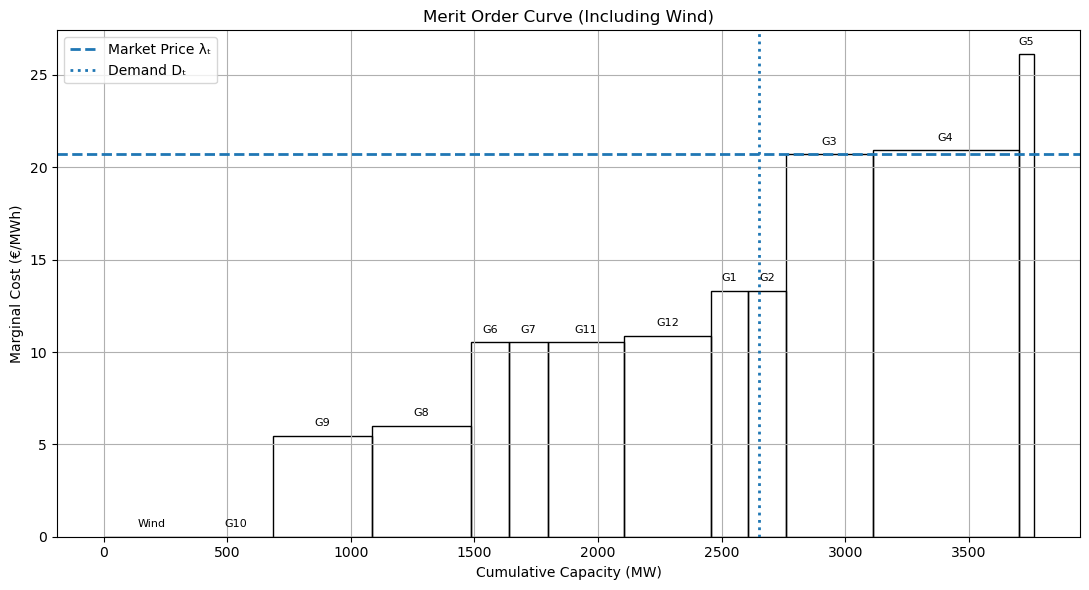

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# Generator Data
# -------------------------------

gen_data = pd.DataFrame({
    "unit": [f"G{i}" for i in range(1, 13)],
    "Pmax": [152, 152, 350, 591, 60, 155, 155, 400, 400, 300, 310, 350],
    "cost": [13.32, 13.32, 20.70, 20.93, 26.11, 10.52, 10.52,
             6.02, 5.47, 0.00, 10.52, 10.89]
})

# Wind block (from model)
P_w_bar_total = sum(P_w_bar.values())  # use your computed value
wind_block = pd.DataFrame({
    "unit": ["Wind"],
    "Pmax": [P_w_bar_total],
    "cost": [0.0]
})

# Combine wind + conventional
supply_data = pd.concat([wind_block, gen_data], ignore_index=True)

# Sort by marginal cost
supply_sorted = supply_data.sort_values("cost").reset_index(drop=True)

# Market price and demand
lambda_t = 20.70
D_t = 2650.5

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(11, 6))

cumulative_capacity = 0

for i in range(len(supply_sorted)):
    capacity = supply_sorted.loc[i, "Pmax"]
    cost = supply_sorted.loc[i, "cost"]
    label = supply_sorted.loc[i, "unit"]

    plt.bar(
        cumulative_capacity,
        cost,
        width=capacity,
        align='edge',
        edgecolor='black',
        fill=False
    )

    plt.text(
        cumulative_capacity + capacity/2,
        cost + 0.5,
        label,
        ha='center',
        fontsize=8
    )

    cumulative_capacity += capacity

# Market clearing price
plt.axhline(lambda_t, linestyle='--', linewidth=2, label="Market Price λₜ")

# Demand
plt.axvline(D_t, linestyle=':', linewidth=2, label="Demand Dₜ")

plt.xlabel("Cumulative Capacity (MW)")
plt.ylabel("Marginal Cost (€/MWh)")
plt.title("Merit Order Curve (Including Wind)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6 – Reserve Market

## Motivation

In the European market design, the reserve capacity market is cleared **before** the day-ahead energy market.  
A subset of conventional generators is assumed to provide reserve services.

We consider:

- **Upward reserve requirement** equal to 15% of total demand
- **Downward reserve requirement** equal to 10% of total demand

Only the same flexible conventional generators as in Step 5 participate in the reserve market.

---

## Reserve Market Formulation

The reserve procurement problem is:

$$
\min \sum_{i \in \mathcal{G}^{flex}} C_i^{R+} r_i^+
+
\sum_{i \in \mathcal{G}^{flex}} C_i^{R-} r_i^-
$$

subject to:

$$
\sum_{i \in \mathcal{G}^{flex}} r_i^+ = R^{up}
$$

$$
\sum_{i \in \mathcal{G}^{flex}} r_i^- = R^{down}
$$

$$
0 \le r_i^+ \le \bar{R}_i^+
$$

$$
0 \le r_i^- \le \bar{R}_i^-
$$

where:

- $r_i^+$ is the upward reserve capacity awarded to generator $i$
- $r_i^-$ is the downward reserve capacity awarded to generator $i$
- $R^{up}$ and $R^{down}$ are the system reserve requirements

The dual variables of the reserve requirement constraints define the reserve market-clearing prices.

---

## Coupling with the Day-Ahead Market

After reserve procurement, the day-ahead energy market is cleared with reduced feasible dispatch for reserve providers:

$$
r_i^{-*} \le p_i \le P_i^{\max} - r_i^{+*}
\qquad \forall i \in \mathcal{G}^{flex}
$$

Thus, reserve procurement can change the day-ahead electricity price by withholding generation capacity from the energy market.

In [62]:
# ============================================
# STEP 6 — RESERVE MARKET PARAMETERS
# ============================================

print("\n========== RESERVE MARKET INPUTS ==========")

# Same flexible generators as in Step 5
# [1,2,3,4,5,6] in 0-based indexing = G2...G7
flexible_generators = [1, 2, 3, 4, 5, 6]

# Reserve requirements
R_up_req = 0.15 * D_t
R_down_req = 0.10 * D_t

print(f"Total demand D_t: {D_t:.2f} MW")
print(f"Upward reserve requirement: {R_up_req:.2f} MW")
print(f"Downward reserve requirement: {R_down_req:.2f} MW")

# Reserve capacity limits
# For now use the technical reserve capacities from the RTS data if available,
# otherwise use simple assumptions based on max capacity.

R_up_max = {
    1: 40,   # G2
    2: 70,   # G3
    3: 180,  # G4
    4: 60,   # G5
    5: 30,   # G6
    6: 30,   # G7
}

R_down_max = {
    1: 40,   # G2
    2: 70,   # G3
    3: 180,  # G4
    4: 60,   # G5
    5: 30,   # G6
    6: 30,   # G7
}

# Reserve bid prices (capacity prices, €/MW)
# Simple assumption: upward reserve is a bit more expensive than downward reserve
C_res_up = {i: 0.10 * C[i] for i in flexible_generators}
C_res_down = {i: 0.05 * C[i] for i in flexible_generators}

print("\nFlexible generators:")
for i in flexible_generators:
    print(
        f"G{i+1}: "
        f"R_up_max={R_up_max[i]} MW, "
        f"R_down_max={R_down_max[i]} MW, "
        f"C_res_up={C_res_up[i]:.2f} €/MW, "
        f"C_res_down={C_res_down[i]:.2f} €/MW"
    )


========== RESERVE MARKET INPUTS ==========
Total demand D_t: 2650.50 MW
Upward reserve requirement: 397.57 MW
Downward reserve requirement: 265.05 MW

Flexible generators:
G2: R_up_max=40 MW, R_down_max=40 MW, C_res_up=1.33 €/MW, C_res_down=0.67 €/MW
G3: R_up_max=70 MW, R_down_max=70 MW, C_res_up=2.07 €/MW, C_res_down=1.03 €/MW
G4: R_up_max=180 MW, R_down_max=180 MW, C_res_up=2.09 €/MW, C_res_down=1.05 €/MW
G5: R_up_max=60 MW, R_down_max=60 MW, C_res_up=2.61 €/MW, C_res_down=1.31 €/MW
G6: R_up_max=30 MW, R_down_max=30 MW, C_res_up=1.05 €/MW, C_res_down=0.53 €/MW
G7: R_up_max=30 MW, R_down_max=30 MW, C_res_up=1.05 €/MW, C_res_down=0.53 €/MW


In [63]:
# ============================================
# STEP 6 — RESERVE MARKET CLEARING
# ============================================

print("\n========== RESERVE MARKET CLEARING ==========")

reserve_model = gp.Model("ReserveMarket")

# -----------------------------
# Decision variables
# -----------------------------
r_up = reserve_model.addVars(
    flexible_generators,
    lb=0,
    ub={i: R_up_max[i] for i in flexible_generators},
    name="r_up"
)

r_down = reserve_model.addVars(
    flexible_generators,
    lb=0,
    ub={i: R_down_max[i] for i in flexible_generators},
    name="r_down"
)

# -----------------------------
# Objective
# -----------------------------
reserve_model.setObjective(
    gp.quicksum(C_res_up[i] * r_up[i] for i in flexible_generators)
    +
    gp.quicksum(C_res_down[i] * r_down[i] for i in flexible_generators),
    GRB.MINIMIZE
)

# -----------------------------
# Reserve requirements
# -----------------------------
up_requirement = reserve_model.addConstr(
    gp.quicksum(r_up[i] for i in flexible_generators) == R_up_req,
    name="up_requirement"
)

down_requirement = reserve_model.addConstr(
    gp.quicksum(r_down[i] for i in flexible_generators) == R_down_req,
    name="down_requirement"
)

# -----------------------------
# Solve
# -----------------------------
reserve_model.optimize()

# Initialize dictionaries
r_up_awarded = {}
r_down_awarded = {}

# -----------------------------
# Results
# -----------------------------
if reserve_model.status == GRB.OPTIMAL:

    lambda_res_up = up_requirement.Pi
    lambda_res_down = down_requirement.Pi

    print(f"\nUpward reserve price: {lambda_res_up:.2f} €/MW")
    print(f"Downward reserve price: {lambda_res_down:.2f} €/MW")

     # Store reserve awards as dictionaries
    r_up_awarded = {i: r_up[i].X for i in flexible_generators}
    r_down_awarded = {i: r_down[i].X for i in flexible_generators}

    print("\nAwarded upward reserve:")
    for i in flexible_generators:
        print(f"G{i+1}: {r_up[i].X:.2f} MW")

    print("\nAwarded downward reserve:")
    for i in flexible_generators:
        print(f"G{i+1}: {r_down[i].X:.2f} MW")

else:
    print(f"Model did not solve optimally. Status: {reserve_model.status}")


========== RESERVE MARKET CLEARING ==========
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 2 rows, 12 columns and 12 nonzeros (Min)
Model fingerprint: 0x14fe6d21
Model has 12 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-01, 3e+00]
  Bounds range     [3e+01, 2e+02]
  RHS range        [3e+02, 4e+02]

Presolve removed 2 rows and 12 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    9.9237815e+02   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective  9.923781500e+02

Upward reserve price: 2.61 €/MW
Downward reserve price: 1.05 €/MW

Awarded upward reserve:
G2: 40.00 MW
G3: 70.00 MW
G4: 180.00 MW
G5: 47.57 MW
G6: 3

## Day-Ahead Market After Reserve Procurement

Once reserve capacities are awarded, the day-ahead energy market is cleared subject to the remaining available generation capacity.

For reserve providers, the feasible dispatch becomes:

$$
r_i^{-*} \le p_i \le P_i^{\max} - r_i^{+*}
$$

This means that:

- upward reserve reduces the maximum energy that can be sold in the day-ahead market
- downward reserve imposes a minimum dispatch level

Hence, reserve procurement may increase the day-ahead electricity price by tightening the supply available for energy dispatch.

In [64]:
# ============================================
# STEP 6 — DAY-AHEAD MARKET AFTER RESERVE
# ============================================

# Only run day-ahead market if reserve market solved
if r_up_awarded and r_down_awarded:

    da_model = gp.Model("DayAhead_with_Reserve")

    # -----------------------------
    # Decision variables
    # -----------------------------
    p_i = da_model.addVars(
        G,
        lb=0,
        ub={i: P_max[i] for i in G},
        name="p_i"
    )

    p_w = da_model.addVars(
        W,
        lb=0,
        ub={w: P_w_bar[w] for w in W},
        name="p_w"
    )

    d_d = da_model.addVar(lb=0, ub=D_t, name="d_d")

    # -----------------------------
    # Objective
    # -----------------------------
    da_model.setObjective(
        gp.quicksum(C[i] * p_i[i] for i in G)
        - U_d * d_d,
        GRB.MINIMIZE
    )

    # -----------------------------
    # Power balance
    # -----------------------------
    balance = da_model.addConstr(
        gp.quicksum(p_i[i] for i in G)
        + gp.quicksum(p_w[w] for w in W)
        == d_d,
        name="power_balance"
    )

    # -----------------------------
    # Coupling with reserve awards
    # -----------------------------
    for i in flexible_generators:
        da_model.addConstr(
            p_i[i] >= r_down_awarded[i],
            name=f"min_dispatch_after_downreserve_{i}"
        )

        da_model.addConstr(
            p_i[i] <= P_max[i] - r_up_awarded[i],
            name=f"max_dispatch_after_upreserve_{i}"
        )

    # -----------------------------
    # Solve
    # -----------------------------
    da_model.optimize()

    # -----------------------------
    # Results
    # -----------------------------
    lambda_DA_reserve = balance.Pi

    print("\n========== DAY-AHEAD MARKET WITH RESERVE ==========")
    print(f"Day-ahead electricity price: {lambda_DA_reserve:.2f} €/MWh")
    print(f"Demand served: {d_d.X:.2f} MW")

    print("\nConventional generation dispatch:")
    for i in G:
        print(f"G{i+1}: {p_i[i].X:.2f} MW")

    print("\nWind generation dispatch:")
    for w in W:
        print(f"W{w}: {p_w[w].X:.2f} MW")

    total_cost_reserve = sum(C[i] * p_i[i].X for i in G)
    social_welfare_reserve = U_d * d_d.X - total_cost_reserve

    print(f"\nTotal operating cost: {total_cost_reserve:.2f} €")
    print(f"Social welfare: {social_welfare_reserve:.2f} €")

else:
    print("Skipping day-ahead market due to reserve market failure.")

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 13 rows, 19 columns and 31 nonzeros (Min)
Model fingerprint: 0x0bbccfc9
Model has 12 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+02]
  Bounds range     [3e+01, 3e+03]
  RHS range        [1e+01, 4e+02]

Presolve removed 12 rows and 11 columns
Presolve time: 0.00s
Presolved: 1 rows, 8 columns, 8 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.5825960e+05   1.624553e+02   0.000000e+00      0s
       1   -2.4611887e+05   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.00 seconds (0.00 work units)
Optimal objective -2.461188721e+05

========== DAY-AHEAD MARKET WITH RESERVE ==========
Day-ahead electricity price: 13.32 €/MWh
Demand served: 2650.50 MW

Convent

In [65]:
# ============================================
# STEP 6 — COMPARISON TABLE
# ============================================

comparison = pd.DataFrame({
    "Metric": [
        "Upward reserve requirement (MW)",
        "Downward reserve requirement (MW)",
        "Upward reserve price (€/MW)",
        "Downward reserve price (€/MW)",
        "DA price without reserve (€/MWh)",
        "DA price with reserve (€/MWh)",
        "Operating cost without reserve (€)",
        "Operating cost with reserve (€)",
        "Social welfare without reserve (€)",
        "Social welfare with reserve (€)"
    ],
    "Value": [
        R_up_req,
        R_down_req,
        lambda_res_up,
        lambda_res_down,
        lambda_t,
        lambda_DA_reserve,
        total_cost,
        total_cost_reserve,
        social_welfare,
        social_welfare_reserve
    ]
})

display(comparison.round(2))

# ============================================
# STEP 6 — RESERVE AWARD TABLE
# ============================================

reserve_award_df = pd.DataFrame({
    "Generator": [f"G{i+1}" for i in flexible_generators],
    "Upward Reserve Awarded (MW)": [r_up_awarded[i] for i in flexible_generators],
    "Downward Reserve Awarded (MW)": [r_down_awarded[i] for i in flexible_generators],
    "Upward Reserve Limit (MW)": [R_up_max[i] for i in flexible_generators],
    "Downward Reserve Limit (MW)": [R_down_max[i] for i in flexible_generators]
})

display(reserve_award_df.round(2))

# ============================================
# STEP 6 — DISPATCH COMPARISON TABLE
# ============================================

dispatch_compare = pd.DataFrame({
    "Generator": [f"G{i+1}" for i in G],
    "Dispatch without Reserve (MW)": [model.getVarByName(f"p_i[{i}]").X for i in G],
    "Dispatch with Reserve (MW)": [p_i[i].X for i in G],
})

dispatch_compare["Difference (MW)"] = (
    dispatch_compare["Dispatch with Reserve (MW)"]
    - dispatch_compare["Dispatch without Reserve (MW)"]
)

display(dispatch_compare.round(2))

,Metric,Value
0,Upward reserve requirement (MW),397.58
1,Downward reserve requirement (MW),265.05
2,Upward reserve price (€/MW),2.61
3,Downward reserve price (€/MW),1.05
4,DA price without reserve (€/MWh),20.70
5,DA price with reserve (€/MWh),13.32
6,Operating cost without reserve (€),17523.20
7,Operating cost with reserve (€),18931.13
8,Social welfare without reserve (€),247526.80
9,Social welfare with reserve (€),246118.87


,Generator,Upward Reserve Awarded (MW),Downward Reserve Awarded (MW),Upward Reserve Limit (MW),Downward Reserve Limit (MW)
0,G2,40.00,40.00,40,40
1,G3,70.00,70.00,70,70
2,G4,180.00,95.05,180,180
3,G5,47.57,0.00,60,60
4,G6,30.00,30.00,30,30
5,G7,30.00,30.00,30,30


,Generator,Dispatch without Reserve (MW),Dispatch with Reserve (MW),Difference (MW)
0,G1,42.69,49.64,6.95
1,G2,152.00,40.00,-112.00
2,G3,0.00,70.00,70.00
3,G4,0.00,95.05,95.05
4,G5,0.00,0.00,0.00
5,G6,155.00,125.00,-30.00
6,G7,155.00,125.00,-30.00
7,G8,400.00,400.00,0.00
8,G9,400.00,400.00,0.00
9,G10,300.00,300.00,0.00


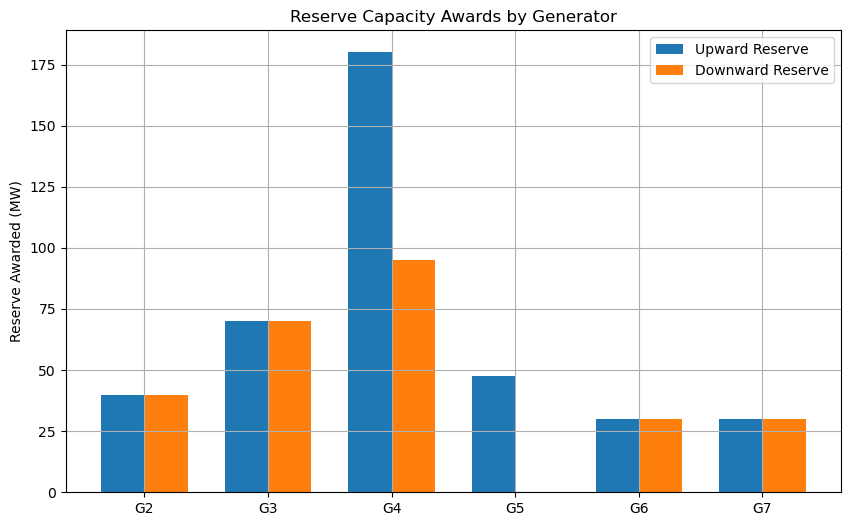

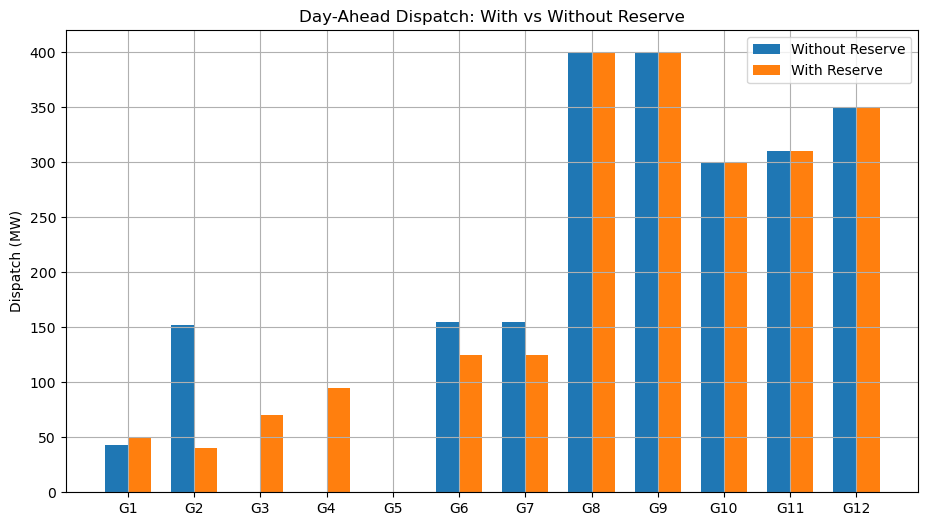

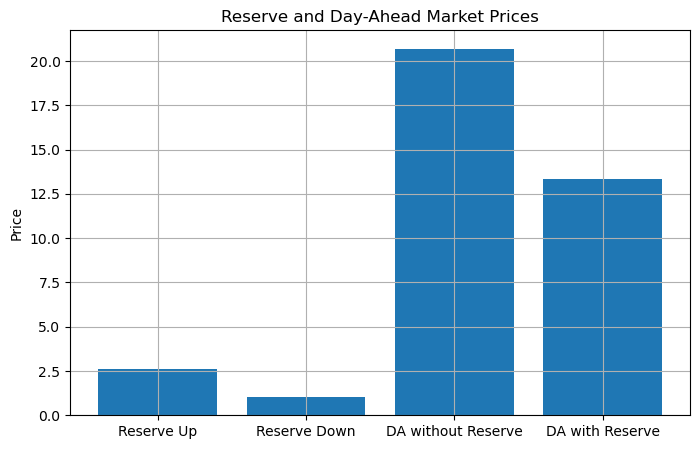

In [66]:
# ============================================
# STEP 6 — RESERVE AWARDS PLOT
# ============================================

plt.figure(figsize=(10,6))

x = np.arange(len(flexible_generators))
width = 0.35

plt.bar(
    x - width/2,
    [r_up_awarded[i] for i in flexible_generators],
    width=width,
    label="Upward Reserve"
)

plt.bar(
    x + width/2,
    [r_down_awarded[i] for i in flexible_generators],
    width=width,
    label="Downward Reserve"
)

plt.xticks(x, [f"G{i+1}" for i in flexible_generators])
plt.ylabel("Reserve Awarded (MW)")
plt.title("Reserve Capacity Awards by Generator")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# STEP 6 — DISPATCH COMPARISON PLOT
# ============================================

plt.figure(figsize=(11,6))

x = np.arange(len(G))
width = 0.35

dispatch_without = [model.getVarByName(f"p_i[{i}]").X for i in G]
dispatch_with = [p_i[i].X for i in G]

plt.bar(x - width/2, dispatch_without, width=width, label="Without Reserve")
plt.bar(x + width/2, dispatch_with, width=width, label="With Reserve")

plt.xticks(x, [f"G{i+1}" for i in G])
plt.ylabel("Dispatch (MW)")
plt.title("Day-Ahead Dispatch: With vs Without Reserve")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# STEP 6 — PRICE COMPARISON PLOT
# ============================================

price_df = pd.DataFrame({
    "Price Type": [
        "Reserve Up",
        "Reserve Down",
        "DA without Reserve",
        "DA with Reserve"
    ],
    "Price": [
        lambda_res_up,
        lambda_res_down,
        lambda_t,
        lambda_DA_reserve
    ]
})

plt.figure(figsize=(8,5))
plt.bar(price_df["Price Type"], price_df["Price"])
plt.ylabel("Price")
plt.title("Reserve and Day-Ahead Market Prices")
plt.grid(True)
plt.show()

## Optional Task: U.S.-Style Joint Energy and Reserve Market

In contrast to the European market design, where reserve and energy markets are cleared sequentially, the U.S.-style approach co-optimizes both within a single day-ahead market-clearing problem.

Demand is assumed to be perfectly inelastic ($d_t = D_t$). The objective is to minimize the total system cost, including both energy production and reserve procurement:

$$
\min \sum_{i \in \mathcal{G}} C_i p_i
+
\sum_{i \in \mathcal{G}^{flex}} \left( C_i^{R+} R_i^+ + C_i^{R-} R_i^- \right)
$$

subject to:

$$
\sum_i p_i + \sum_w p_w = D_t
$$

$$
\sum_i R_i^+ = \bar{R}^+, \quad
\sum_i R_i^- = \bar{R}^-
$$

$$
p_i + R_i^+ \le P_i^{\max}, \quad
R_i^- \le p_i, \quad \forall i \in \mathcal{G}^{flex}
$$

The dual variables of the energy balance and reserve constraints define the energy and reserve market-clearing prices, respectively.

In [67]:
# ============================================
# OPTIONAL TASK — U.S.-STYLE JOINT MARKET
# ============================================

us_model = gp.Model("US_joint_market")

# -----------------------------
# Variables
# -----------------------------
p_i_us = us_model.addVars(
    G,
    lb=0,
    ub={i: P_max[i] for i in G},
    name="p_i"
)

p_w_us = us_model.addVars(
    W,
    lb=0,
    ub={w: P_w_bar[w] for w in W},
    name="p_w"
)

R_up_us = us_model.addVars(
    flexible_generators,
    lb=0,
    ub={i: R_up_max[i] for i in flexible_generators},
    name="R_up"
)

R_down_us = us_model.addVars(
    flexible_generators,
    lb=0,
    ub={i: R_down_max[i] for i in flexible_generators},
    name="R_down"
)

# -----------------------------
# Objective
# -----------------------------
us_model.setObjective(
    gp.quicksum(C[i] * p_i_us[i] for i in G)
    + gp.quicksum(C_res_up[i] * R_up_us[i] for i in flexible_generators)
    + gp.quicksum(C_res_down[i] * R_down_us[i] for i in flexible_generators),
    GRB.MINIMIZE
)

# -----------------------------
# Constraints
# -----------------------------
balance_us = us_model.addConstr(
    gp.quicksum(p_i_us[i] for i in G)
    + gp.quicksum(p_w_us[w] for w in W)
    == D_t,
    name="power_balance"
)

up_req_us = us_model.addConstr(
    gp.quicksum(R_up_us[i] for i in flexible_generators) == R_up_req,
    name="up_reserve"
)

down_req_us = us_model.addConstr(
    gp.quicksum(R_down_us[i] for i in flexible_generators) == R_down_req,
    name="down_reserve"
)

# Coupling
for i in flexible_generators:
    us_model.addConstr(p_i_us[i] + R_up_us[i] <= P_max[i])
    us_model.addConstr(R_down_us[i] <= p_i_us[i])

# Solve
us_model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 15 rows, 30 columns and 54 nonzeros (Min)
Model fingerprint: 0x79d56694
Model has 23 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-01, 3e+01]
  Bounds range     [3e+01, 6e+02]
  RHS range        [6e+01, 3e+03]

Presolve removed 3 rows and 10 columns
Presolve time: 0.00s
Presolved: 12 rows, 20 columns, 51 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.8651907e+04   9.392568e+01   0.000000e+00      0s
       5    1.9908087e+04   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.990808667e+04


In [68]:
# ============================================
# RESULTS
# ============================================

lambda_us = balance_us.Pi
lambda_R_up_us = up_req_us.Pi
lambda_R_down_us = down_req_us.Pi

energy_cost_us = sum(C[i] * p_i_us[i].X for i in G)
reserve_cost_us = (
    sum(C_res_up[i] * R_up_us[i].X for i in flexible_generators)
    + sum(C_res_down[i] * R_down_us[i].X for i in flexible_generators)
)

total_cost_us = energy_cost_us + reserve_cost_us

print("\n========== U.S.-STYLE MARKET ==========")
print(f"Energy price: {lambda_us:.2f} €/MWh")
print(f"Up reserve price: {lambda_R_up_us:.2f} €/MW")
print(f"Down reserve price: {lambda_R_down_us:.2f} €/MW")
print(f"Total system cost: {total_cost_us:.2f} €")


========== U.S.-STYLE MARKET ==========
Energy price: 13.32 €/MWh
Up reserve price: 3.85 €/MW
Down reserve price: 8.66 €/MW
Total system cost: 19908.09 €


In [69]:
# ============================================
# COMPARISON: EU vs US
# ============================================

comparison_us = pd.DataFrame({
    "Metric": [
        "Electricity price (€/MWh)",
        "Up reserve price (€/MW)",
        "Down reserve price (€/MW)",
        "Total cost (€)"
    ],
    "European (Sequential)": [
        lambda_DA_reserve,
        lambda_res_up,
        lambda_res_down,
        total_cost_reserve
    ],
    "U.S. (Joint)": [
        lambda_us,
        lambda_R_up_us,
        lambda_R_down_us,
        total_cost_us
    ]
})

display(comparison_us.round(2))

,Metric,European (Sequential),U.S. (Joint)
0,Electricity price (€/MWh),13.32,13.32
1,Up reserve price (€/MW),2.61,3.85
2,Down reserve price (€/MW),1.05,8.66
3,Total cost (€),18931.13,19908.09
